# Data Cleaning

In [2]:
import pandas as pd

In [3]:
per_game = pd.read_csv("Player Per Game.csv")
advanced = pd.read_csv("Advanced.csv")
all_star = pd.read_csv("All-Star Selections.csv")

In [4]:
per_game.columns = per_game.columns.str.strip().str.lower()
advanced.columns = advanced.columns.str.strip().str.lower()
all_star.columns = all_star.columns.str.strip().str.lower()

In [5]:
df = pd.merge(
    per_game,
    advanced,
    on=["player_id", "season"],
    how="inner",
    suffixes=("_pg", "_adv")
)

all_star["allstar"] = 1

all_star_labels = all_star[["player_id", "season", "allstar"]].drop_duplicates()

df = pd.merge(
    df,
    all_star_labels,
    on=["player_id", "season"],
    how="left"
)

df["allstar"] = df["allstar"].fillna(0).astype(int)

In [6]:
print("===== DATASET STATISTICS =====\n")

print(f"Number of records: {df.shape[0]}")
print(f"Number of columns (including target): {df.shape[1]}")

print("\nFeature types:")
print(df.dtypes.value_counts())

print("\nMissing values by column (top 15):")
print(df.isnull().sum().sort_values(ascending=False).head(15))

print("\nClass distribution:")
print(df["allstar"].value_counts())

print("\nClass distribution (%):")
print((df["allstar"].value_counts(normalize=True) * 100).round(2))

print("\nColumns:")
print(df.columns.tolist())

===== DATASET STATISTICS =====

Number of records: 52984
Number of columns (including target): 61

Feature types:
float64    48
object      9
int64       3
int32       1
Name: count, dtype: int64

Missing values by column (top 15):
x3p_percent      17527
gs_pg            13118
gs_adv           13067
x2p_percent      10432
x3p_ar           10251
e_fg_percent     10250
x3pa_per_game     9959
x2pa_per_game     9958
x2p_per_game      9958
x3p_per_game      9958
dbpm              9211
obpm              9211
bpm               9211
vorp              9201
stl_percent       9154
dtype: int64

Class distribution:
allstar
0    50526
1     2458
Name: count, dtype: int64

Class distribution (%):
allstar
0    95.36
1     4.64
Name: proportion, dtype: float64

Columns:
['season', 'lg_pg', 'player_pg', 'player_id', 'age_pg', 'team_pg', 'pos_pg', 'g_pg', 'gs_pg', 'mp_per_game', 'fg_per_game', 'fga_per_game', 'fg_percent', 'x3p_per_game', 'x3pa_per_game', 'x3p_percent', 'x2p_per_game', 'x2pa_per_game', 

# Exploratory Data Analysis

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

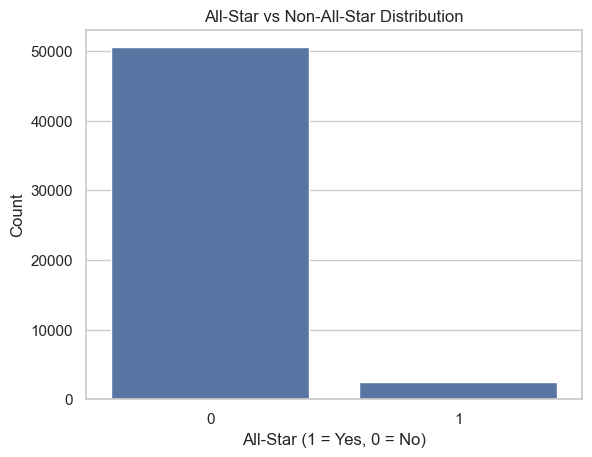

In [9]:
sns.countplot(x="allstar", data=df)
plt.title("All-Star vs Non-All-Star Distribution")
plt.xlabel("All-Star (1 = Yes, 0 = No)")
plt.ylabel("Count")
plt.show()

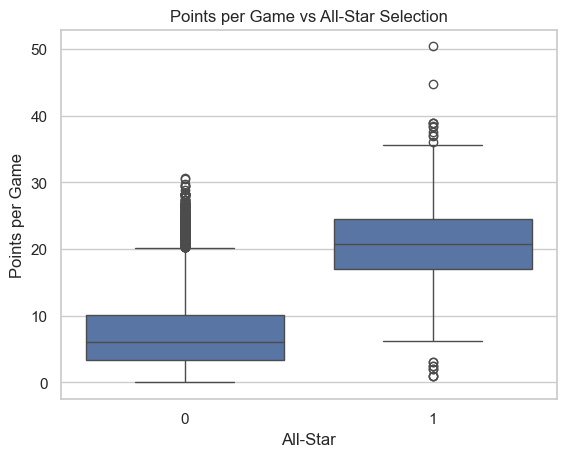

In [10]:
sns.boxplot(x="allstar", y="pts_per_game", data=df)
plt.title("Points per Game vs All-Star Selection")
plt.xlabel("All-Star")
plt.ylabel("Points per Game")
plt.show()

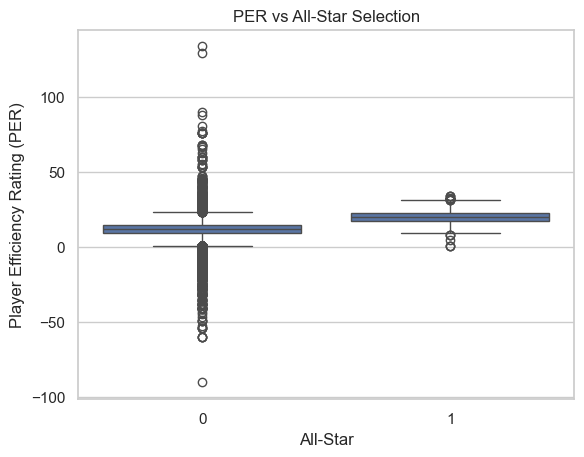

In [11]:
sns.boxplot(x="allstar", y="per", data=df)
plt.title("PER vs All-Star Selection")
plt.xlabel("All-Star")
plt.ylabel("Player Efficiency Rating (PER)")
plt.show()

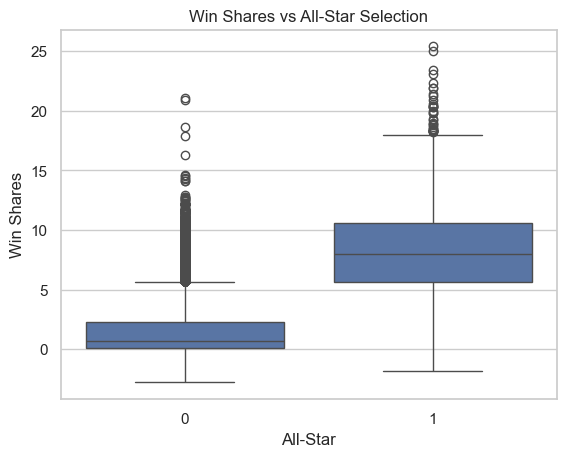

In [12]:
sns.boxplot(x="allstar", y="ws", data=df)
plt.title("Win Shares vs All-Star Selection")
plt.xlabel("All-Star")
plt.ylabel("Win Shares")
plt.show()

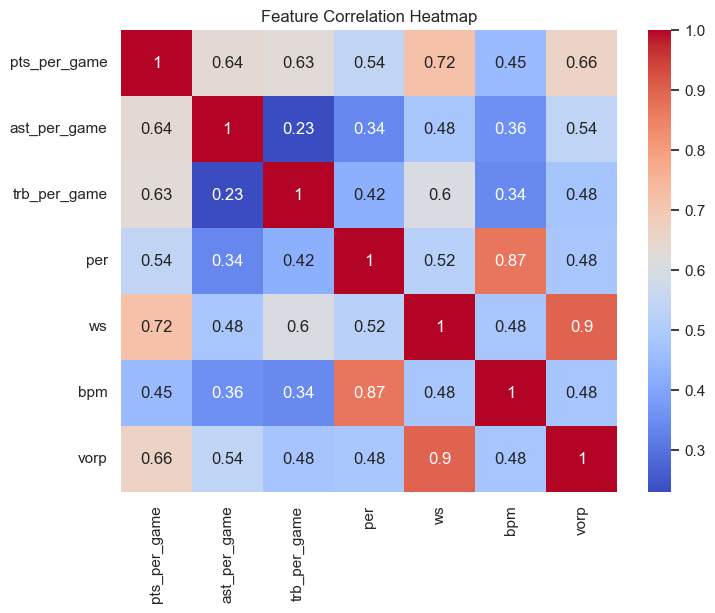

In [13]:
features = ["pts_per_game", "ast_per_game", "trb_per_game", "per", "ws", "bpm", "vorp"]

corr = df[features].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()

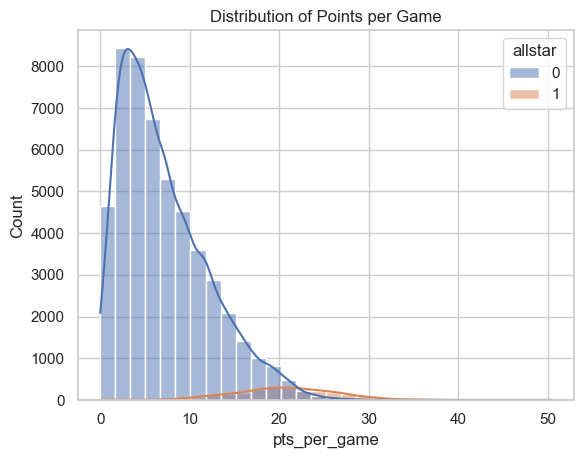

In [14]:
sns.histplot(data=df, x="pts_per_game", hue="allstar", bins=30, kde=True)
plt.title("Distribution of Points per Game")
plt.show()

## Feature Selection & Filtering

We apply filters to produce a clean modeling dataset:
- **Modern era only (1980+):** Advanced metrics are very sparse before 1980.
- **Minimum 20 games played:** Removes players with tiny sample sizes who would never realistically be All-Star candidates.
- **Drop identifier/duplicate columns:** Keep only numeric performance features.
- **Fill remaining NaNs with 0:** Primarily `x3p_percent` for players who never attempted a three-pointer, `ft_percent` for 0 FTA, etc.

In [16]:
# filter to modern era, minimum games
df = df[(df["season"] >= 1980) & (df["g_pg"] >= 20)].copy()
print(f"After filtering: {df.shape[0]} rows")
print(f"\nClass distribution:")
print(df["allstar"].value_counts())
print(f"\nAll-Star rate: {df['allstar'].mean()*100:.2f}%")

After filtering: 29093 rows

Class distribution:
allstar
0    27779
1     1314
Name: count, dtype: int64

All-Star rate: 4.52%


In [17]:
# drop non-feature columns
drop_cols = [
    "season", "lg_pg", "player_pg", "player_id", "team_pg", "pos_pg",
    "lg_adv", "player_adv", "team_adv", "pos_adv",
    "age_adv", "g_adv", "gs_adv", "gs_pg",  # duplicates from merge
    "allstar"
]
feature_cols = [c for c in df.columns if c not in drop_cols]

X = df[feature_cols].copy().fillna(0)
y = df["allstar"].copy()

print(f"Number of features: {len(feature_cols)}")
print(f"Features:\n{feature_cols}")
print(f"\nX shape: {X.shape}")
print(f"Any NaNs remaining: {X.isnull().any().any()}")

Number of features: 46
Features:
['age_pg', 'g_pg', 'mp_per_game', 'fg_per_game', 'fga_per_game', 'fg_percent', 'x3p_per_game', 'x3pa_per_game', 'x3p_percent', 'x2p_per_game', 'x2pa_per_game', 'x2p_percent', 'e_fg_percent', 'ft_per_game', 'fta_per_game', 'ft_percent', 'orb_per_game', 'drb_per_game', 'trb_per_game', 'ast_per_game', 'stl_per_game', 'blk_per_game', 'tov_per_game', 'pf_per_game', 'pts_per_game', 'mp', 'per', 'ts_percent', 'x3p_ar', 'f_tr', 'orb_percent', 'drb_percent', 'trb_percent', 'ast_percent', 'stl_percent', 'blk_percent', 'tov_percent', 'usg_percent', 'ows', 'dws', 'ws', 'ws_48', 'obpm', 'dbpm', 'bpm', 'vorp']

X shape: (29093, 46)
Any NaNs remaining: False


## Model Training & Evaluation

We train five classification models:

1. **Logistic Regression** -- discriminative baseline
2. **Regularized Logistic Regression (L1 / Lasso)** -- automatic feature selection via sparsity
3. **Gaussian Naive Bayes** -- generative baseline assuming feature independence
4. **Linear Discriminant Analysis (LDA)** -- generative model with shared covariance
5. **Quadratic Discriminant Analysis (QDA)** -- generative model with per-class covariance

This allows us to compare discriminative vs. generative approaches and linear vs. quadratic decision boundaries.

### Train/Test Split & Standardization

We use an 80/20 stratified split to preserve the class imbalance ratio in both sets, then standardize features using training set statistics only (to avoid data leakage).

In [20]:
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, auc, f1_score, precision_score, recall_score,
    accuracy_score, roc_auc_score, precision_recall_curve
)

In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {X_train.shape[0]} samples ({y_train.mean()*100:.2f}% All-Star)")
print(f"Test:  {X_test.shape[0]} samples ({y_test.mean()*100:.2f}% All-Star)")

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Train: 23274 samples (4.52% All-Star)
Test:  5819 samples (4.52% All-Star)


### Stratified 5-Fold Cross-Validation

In [ ]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Lasso Logistic (L1)": LogisticRegression(penalty="l1", solver="saga", max_iter=10000, C=1.0, random_state=42),
    "Gaussian Naive Bayes": GaussianNB(),
    "LDA": LinearDiscriminantAnalysis(),
    "QDA": QuadraticDiscriminantAnalysis(reg_param=0.1),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = ["accuracy", "f1", "precision", "recall", "roc_auc"]

cv_results = {}
for name, model in models.items():
    print(f"Training {name}...")
    scores = cross_validate(model, X_train_scaled, y_train, cv=cv, scoring=scoring, return_train_score=False)
    cv_results[name] = {metric: scores[f"test_{metric}"].mean() for metric in scoring}
    print(f"  CV AUC: {cv_results[name]['roc_auc']:.4f} | F1: {cv_results[name]['f1']:.4f}")

Training Logistic Regression...
  CV AUC: 0.9868 | F1: 0.6966
Training Lasso Logistic (L1)...


In [ ]:
cv_df = pd.DataFrame(cv_results).T
cv_df.columns = ["Accuracy", "F1", "Precision", "Recall", "AUC-ROC"]
cv_df = cv_df.round(4)
print("===== Cross-Validation Results (5-Fold, Training Set) =====")
print()
print(cv_df.to_string())

### Test Set Evaluation

In [ ]:
test_results = {}
fitted_models = {}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    fitted_models[name] = model

    y_pred = model.predict(X_test_scaled)
    y_prob = model.predict_proba(X_test_scaled)[:, 1]

    test_results[name] = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "AUC-ROC": roc_auc_score(y_test, y_prob),
    }

test_df = pd.DataFrame(test_results).T.round(4)
print("===== Test Set Results =====")
print()
print(test_df.to_string())

### ROC Curves

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))

for name, model in fitted_models.items():
    y_prob = model.predict_proba(X_test_scaled)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc_val = auc(fpr, tpr)
    ax.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc_val:.3f})")

ax.plot([0, 1], [0, 1], "k--", alpha=0.5, label="Random Classifier")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curves -- Baseline Models")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

### Confusion Matrices

In [ ]:
fig, axes = plt.subplots(1, 5, figsize=(22, 4))

for ax, (name, model) in zip(axes, fitted_models.items()):
    y_pred = model.predict(X_test_scaled)
    cm = confusion_matrix(y_test, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=["Not AS", "All-Star"]).plot(ax=ax, cmap="Blues", colorbar=False)
    ax.set_title(name, fontsize=10)

plt.suptitle("Confusion Matrices -- Test Set", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### Feature Importance (Lasso Logistic Regression)

The L1-regularized logistic regression drives irrelevant coefficients to zero, giving us a natural ranking of the most important features for predicting All-Star selection.

In [ ]:
lasso_model = fitted_models["Lasso Logistic (L1)"]
coef_df = pd.DataFrame({
    "Feature": feature_cols,
    "Coefficient": lasso_model.coef_[0]
}).assign(AbsCoef=lambda d: d["Coefficient"].abs()).sort_values("AbsCoef", ascending=False)

print("===== Top 15 Features by |Coefficient| (Lasso Logistic) =====\n")
print(coef_df.head(15)[["Feature", "Coefficient"]].to_string(index=False))

In [ ]:
top_n = 15
top = coef_df.head(top_n)

fig, ax = plt.subplots(figsize=(8, 6))
colors = ["#e74c3c" if c > 0 else "#3498db" for c in top["Coefficient"]]
ax.barh(top["Feature"][::-1], top["Coefficient"][::-1], color=colors[::-1])
ax.set_xlabel("Coefficient")
ax.set_title("Top 15 Feature Coefficients -- Lasso Logistic Regression")
ax.axvline(x=0, color="black", linewidth=0.5)
plt.tight_layout()
plt.show()

### Detailed Classification Report (Best Model)

In [ ]:
best_name = test_df["AUC-ROC"].idxmax()
best_model = fitted_models[best_name]
print(f"Best model by AUC-ROC: {best_name}\n")
y_pred_best = best_model.predict(X_test_scaled)
print(classification_report(y_test, y_pred_best, target_names=["Not All-Star", "All-Star"]))

## Additional Models: Tree-Based Methods

We extend the comparison with two tree-based ensemble methods:

1. **Random Forest** -- builds many decision trees on random subsets of data and features, reducing variance through averaging
2. **Gradient Boosting** -- builds trees sequentially, each correcting errors of the previous, reducing bias through boosting

Unlike logistic regression, tree-based models can capture nonlinear interactions between features (e.g., high scoring AND high usage together) without feature engineering. We apply the same scaled data for a consistent comparison across all models.

In [ ]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

### Cross-Validation (Tree Models)

In [ ]:
tree_models = {
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=200, learning_rate=0.1, max_depth=4, random_state=42),
}

tree_cv_results = {}
for name, model in tree_models.items():
    print(f"Training {name}...")
    scores = cross_validate(model, X_train_scaled, y_train, cv=cv, scoring=scoring, return_train_score=False)
    tree_cv_results[name] = {metric: scores[f"test_{metric}"].mean() for metric in scoring}
    print(f"  CV AUC: {tree_cv_results[name]['roc_auc']:.4f} | F1: {tree_cv_results[name]['f1']:.4f}")

In [ ]:
tree_cv_df = pd.DataFrame(tree_cv_results).T
tree_cv_df.columns = ["Accuracy", "F1", "Precision", "Recall", "AUC-ROC"]
tree_cv_df = tree_cv_df.round(4)
print("===== Cross-Validation Results (5-Fold, Training Set) -- Tree Models =====\n")
print(tree_cv_df.to_string())

### Test Set Evaluation (Tree Models)

In [ ]:
tree_test_results = {}
tree_fitted_models = {}

for name, model in tree_models.items():
    model.fit(X_train_scaled, y_train)
    tree_fitted_models[name] = model

    y_pred = model.predict(X_test_scaled)
    y_prob = model.predict_proba(X_test_scaled)[:, 1]

    tree_test_results[name] = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "AUC-ROC": roc_auc_score(y_test, y_prob),
    }

tree_test_df = pd.DataFrame(tree_test_results).T.round(4)
print("===== Test Set Results -- Tree Models =====\n")
print(tree_test_df.to_string())

### Full Model Comparison

In [ ]:
all_test_df = pd.concat([test_df, tree_test_df]).sort_values("AUC-ROC", ascending=False)
print("===== All Models -- Test Set Results (sorted by AUC-ROC) =====\n")
print(all_test_df.to_string())

### ROC Curves (All Models)

In [ ]:
all_fitted = {**fitted_models, **tree_fitted_models}

fig, ax = plt.subplots(figsize=(9, 7))

for name, model in all_fitted.items():
    y_prob = model.predict_proba(X_test_scaled)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc_val = auc(fpr, tpr)
    ax.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc_val:.3f})")

ax.plot([0, 1], [0, 1], "k--", alpha=0.5, label="Random Classifier")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curves -- All Models")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

### Confusion Matrices (Tree Models)

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, (name, model) in zip(axes, tree_fitted_models.items()):
    y_pred = model.predict(X_test_scaled)
    cm = confusion_matrix(y_test, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=["Not AS", "All-Star"]).plot(ax=ax, cmap="Blues", colorbar=False)
    ax.set_title(name, fontsize=10)

plt.suptitle("Confusion Matrices -- Tree Models (Test Set)", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### Feature Importance (Random Forest)

Random Forest provides built-in feature importances based on the average decrease in impurity (Gini) across all trees and splits. This gives a complementary view of feature relevance compared to the Lasso coefficients above.

In [ ]:
rf_model = tree_fitted_models["Random Forest"]
rf_importance_df = pd.DataFrame({
    "Feature": feature_cols,
    "Importance": rf_model.feature_importances_
}).sort_values("Importance", ascending=False)

print("===== Top 15 Features by Importance (Random Forest) =====\n")
print(rf_importance_df.head(15).to_string(index=False))

In [ ]:
top_rf = rf_importance_df.head(15)

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(top_rf["Feature"][::-1], top_rf["Importance"][::-1], color="#2ecc71")
ax.set_xlabel("Feature Importance (Mean Decrease in Impurity)")
ax.set_title("Top 15 Feature Importances -- Random Forest")
plt.tight_layout()
plt.show()

### Detailed Classification Reports (Tree Models)

In [ ]:
for name, model in tree_fitted_models.items():
    y_pred = model.predict(X_test_scaled)
    print(f"===== {name} =====\n")
    print(classification_report(y_test, y_pred, target_names=["Not All-Star", "All-Star"]))
    print()

## Threshold Tuning

By default classifiers predict class 1 when the probability exceeds 0.5. With imbalanced data, a lower threshold can improve recall at a modest precision cost. We use the precision-recall curve to find the threshold that maximizes F1 on the test set.

In [ ]:
best_overall = all_test_df["AUC-ROC"].idxmax()
best_overall_model = all_fitted[best_overall]
y_prob_tuning = best_overall_model.predict_proba(X_test_scaled)[:, 1]

precisions, recalls, thresholds = precision_recall_curve(y_test, y_prob_tuning)
f1_scores_thresh = 2 * precisions[:-1] * recalls[:-1] / (precisions[:-1] + recalls[:-1] + 1e-9)
best_idx = f1_scores_thresh.argmax()
best_threshold = thresholds[best_idx]

print(f"Best model: {best_overall}")
print(f"Optimal threshold (max F1): {best_threshold:.4f}")
print(f"F1 at optimal threshold:    {f1_scores_thresh[best_idx]:.4f}")
print(f"F1 at default threshold (0.5): {f1_score(y_test, best_overall_model.predict(X_test_scaled)):.4f}")

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(thresholds, precisions[:-1], label="Precision")
ax.plot(thresholds, recalls[:-1], label="Recall")
ax.plot(thresholds, f1_scores_thresh, label="F1 Score")
ax.axvline(x=best_threshold, color="red", linestyle="--", label=f"Optimal threshold = {best_threshold:.3f}")
ax.set_xlabel("Threshold")
ax.set_ylabel("Score")
ax.set_title(f"Precision / Recall / F1 vs Threshold ({best_overall})")
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
y_pred_tuned = (y_prob_tuning >= best_threshold).astype(int)
print(f"Classification report at threshold = {best_threshold:.4f} ({best_overall}):\n")
print(classification_report(y_test, y_pred_tuned, target_names=["Not All-Star", "All-Star"]))

## Position Normalization

The bar for All-Star selection varies by position. A point guard scoring 18 ppg may be a borderline candidate while a center with the same output could be a clear All-Star. We normalize each feature within position groups using training set statistics only to capture position-relative performance, then re-evaluate all models on the position-normalized features.

In [ ]:
pos_labels = df.loc[X.index, "pos_pg"].str.split("-").str[0].fillna("F")

print("Position distribution:")
print(pos_labels.value_counts())

train_pos = pos_labels.loc[X_train.index]
test_pos = pos_labels.loc[X_test.index]

X_pos_train = X_train.copy().astype(float)
X_pos_test = X_test.copy().astype(float)

# normalize each feature by position group using training set statistics only
for feat in feature_cols:
    pos_stats = X_train.groupby(train_pos)[feat].agg(["mean", "std"])
    pos_stats["std"] = pos_stats["std"].replace(0, 1).fillna(1)

    X_pos_train[feat] = (X_train[feat] - train_pos.map(pos_stats["mean"])) / train_pos.map(pos_stats["std"])
    X_pos_test[feat] = (X_test[feat] - test_pos.map(pos_stats["mean"])) / test_pos.map(pos_stats["std"])

X_pos_train = X_pos_train.fillna(0)
X_pos_test = X_pos_test.fillna(0)

print(f"\nX_pos_train shape: {X_pos_train.shape}")
print(f"Any NaNs: {X_pos_train.isnull().any().any()}")

In [ ]:
pos_test_results = {}

for name, model in all_fitted.items():
    model.fit(X_pos_train, y_train)
    y_pred = model.predict(X_pos_test)
    y_prob = model.predict_proba(X_pos_test)[:, 1]
    pos_test_results[name] = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "AUC-ROC": roc_auc_score(y_test, y_prob),
    }

pos_test_df = pd.DataFrame(pos_test_results).T.round(4)
print("===== Test Set Results -- Position-Normalized Features =====\n")
print(pos_test_df.sort_values("AUC-ROC", ascending=False).to_string())
print()
print("===== Comparison: Original vs Position-Normalized (AUC-ROC) =====\n")
comparison = pd.DataFrame({
    "Original": all_test_df["AUC-ROC"],
    "Position-Norm": pos_test_df["AUC-ROC"],
}).round(4)
comparison["Delta"] = (comparison["Position-Norm"] - comparison["Original"]).round(4)
print(comparison.to_string())